# Etapa 3 — Sensibilidad cíclica con EMA más rápida

El primer smoke neuronal recuperó el subespacio de fase, pero el predictor y el target EMA quedaron desacoplados. Esta sensibilidad cambia **un solo factor**: `ema_momentum` baja de `0.99` a `0.90`. Seed, datos, arquitectura, losses, optimización, selección y gates permanecen idénticos.

La hipótesis diagnóstica es que un target que siga más rápido al online reducirá el cambio de coordenadas y permitirá interpretar el predictor como endomorfismo. El `FAIL` original permanece intacto. Usamos únicamente train/validation; test no se construye.

In [1]:
# ruff: noqa: E402, E501, I001
import copy
import json
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import yaml
from IPython.display import Markdown, display
from sklearn.decomposition import PCA

from koopman_jepa.config import DataConfig, ExperimentConfig, ModelConfig, TrainConfig, validate_config
from koopman_jepa.koopman import expected_active_spectrum
from koopman_jepa.model import TemporalJEPA
from koopman_jepa.phase_analysis import evaluate_phase_operator_diagnostics, evaluate_phase_representation
from koopman_jepa.phase_data import PhaseWindowConfig, make_phase_tensor_dataset_splits
from koopman_jepa.training import (
    collect_paired_embeddings,
    evaluate_model_loss,
    select_device,
    set_seed,
    train_model_with_validation_checkpoint,
)

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
REFERENCE_PATH = ROOT / "configs" / "stage3_cyclic_neural_smoke.yaml"
CONFIG_PATH = ROOT / "configs" / "stage3_cyclic_neural_ema_fast_smoke.yaml"
with REFERENCE_PATH.open(encoding="utf-8") as handle:
    reference_raw = yaml.safe_load(handle)
with CONFIG_PATH.open(encoding="utf-8") as handle:
    raw = yaml.safe_load(handle)
comparison = copy.deepcopy(raw)
comparison["train"]["ema_momentum"] = reference_raw["train"]["ema_momentum"]
assert comparison == reference_raw
assert reference_raw["train"]["ema_momentum"] == 0.99
assert raw["train"]["ema_momentum"] == 0.90

dynamics = raw["dynamics"]
base_seed = int(raw["base_seed"])
emission_config = PhaseWindowConfig(**raw["emission"], repeats_per_transition=1)
model_raw = raw["model"]
experiment_config = ExperimentConfig(
    data=DataConfig(context_length=emission_config.window_length),
    model=ModelConfig(latent_dim=model_raw["latent_dim"], channels=model_raw["channels"], predictor_init=model_raw["predictor_init"]),
    train=TrainConfig(seed=base_seed, **raw["train"]),
)
validate_config(experiment_config)
splits = make_phase_tensor_dataset_splits(
    emission_config,
    train_repeats_per_transition=raw["splits"]["train_repeats_per_transition"],
    validation_repeats_per_transition=raw["splits"]["validation_repeats_per_transition"],
    seed=base_seed,
)
train_dataset = splits.train[dynamics]
validation_dataset = splits.validation[dynamics]
print(json.dumps({"changed_only": "train.ema_momentum: 0.99 -> 0.90", "train_pairs": len(train_dataset), "validation_pairs": len(validation_dataset), "test_constructed": False}, indent=2))

{
  "changed_only": "train.ema_momentum: 0.99 -> 0.90",
  "train_pairs": 1024,
  "validation_pairs": 256,
  "test_constructed": false
}


In [3]:
set_seed(base_seed)
device = select_device(experiment_config.train.device)
model = TemporalJEPA(
    latent_dim=model_raw["latent_dim"],
    channels=model_raw["channels"],
    predictor_init=model_raw["predictor_init"],
    pooling=model_raw["pooling"],
    input_length=emission_config.window_length,
).to(device)
baseline = evaluate_model_loss(model, validation_dataset, experiment_config, device)
training_result = train_model_with_validation_checkpoint(model, train_dataset, validation_dataset, experiment_config, device)
selected = evaluate_model_loss(model, validation_dataset, experiment_config, device)
history = training_result.history

train_current, _, _, train_phase_pairs = collect_paired_embeddings(model, train_dataset, experiment_config.train.batch_size, device)
validation_current, validation_future_online, validation_future_target, validation_phase_pairs = collect_paired_embeddings(model, validation_dataset, experiment_config.train.batch_size, device)
predictor_matrix = model.predictor.matrix.detach().cpu().numpy()
metrics = evaluate_phase_representation(
    train_current, train_phase_pairs[:, 0], validation_current, validation_phase_pairs[:, 0], predictor_matrix, dynamics, base_seed
)
diagnostics = evaluate_phase_operator_diagnostics(
    validation_current, validation_future_online, validation_future_target, validation_phase_pairs[:, 0], validation_phase_pairs[:, 1], predictor_matrix, dynamics
)
validation_loss_ratio = selected.loss / baseline.loss
history_is_finite = all(np.isfinite(value) for row in history for value in row.values())
summary = {
    "selected_epoch": training_result.best_epoch,
    "validation_loss_ratio": float(validation_loss_ratio),
    "embedding_std_mean": metrics["embedding_std_mean"],
    "effective_rank": metrics["effective_rank"],
    "linear_probe_accuracy": metrics["linear_probe_accuracy"],
    "phase_alignment_error": metrics["phase_alignment_error"],
    "active_rank": metrics["active_rank"],
    "intertwining_error": metrics["intertwining_error"],
    "spectral_max_absolute_error": metrics["spectral_max_absolute_error"],
    "online_target_phase_basis_error": diagnostics["online_target_phase_basis_error"],
    "trained_cross_encoder_error": diagnostics["trained_cross_encoder_error"],
    "posthoc_online_spectral_max_error": diagnostics["posthoc_online_spectral_max_error"],
}
print(json.dumps(summary, indent=2))

epoch=001 train=3.504628 val=2.156640


epoch=006 train=1.395722 val=2.612759


epoch=012 train=1.019673 val=2.289569


epoch=018 train=0.877521 val=2.097630


epoch=024 train=0.801935 val=2.036081


epoch=030 train=0.748216 val=2.127419
{
  "selected_epoch": 27,
  "validation_loss_ratio": 0.4259388829769046,
  "embedding_std_mean": 1.1327047088098678,
  "effective_rank": 2.9273004614417237,
  "linear_probe_accuracy": 1.0,
  "phase_alignment_error": 0.18154599053266085,
  "active_rank": 3,
  "intertwining_error": 0.7586764359976873,
  "spectral_max_absolute_error": 1.0587052342598113,
  "online_target_phase_basis_error": 0.18210091571482942,
  "trained_cross_encoder_error": 0.7447659492295092,
  "posthoc_online_spectral_max_error": 0.045302299854831814
}


In [4]:
gate_config = raw["gates"]
gate_checks = {
    "finite_training": history_is_finite,
    "validation_improves": validation_loss_ratio <= gate_config["maximum_validation_loss_ratio"],
    "embedding_scale": metrics["embedding_std_mean"] >= gate_config["minimum_embedding_std_mean"],
    "effective_rank": metrics["effective_rank"] >= gate_config["minimum_effective_rank"],
    "phase_probe": metrics["linear_probe_accuracy"] >= gate_config["minimum_linear_probe_accuracy"],
    "phase_alignment": metrics["phase_alignment_error"] <= gate_config["maximum_phase_alignment_error"],
    "active_rank": metrics["active_rank"] == gate_config["required_active_rank"],
    "intertwining": metrics["intertwining_error"] <= gate_config["maximum_intertwining_error"],
    "active_invariance": metrics["active_invariance_error"] is not None and metrics["active_invariance_error"] <= gate_config["maximum_active_invariance_error"],
    "spectrum": metrics["spectral_max_absolute_error"] is not None and metrics["spectral_max_absolute_error"] <= gate_config["maximum_spectral_error"],
}
ema_fast_gate_passed = bool(all(gate_checks.values()))
print(json.dumps({**gate_checks, "ema_fast_gate_passed": ema_fast_gate_passed}, indent=2))
assert ema_fast_gate_passed

{
  "finite_training": true,
  "validation_improves": true,
  "embedding_scale": true,
  "effective_rank": true,
  "phase_probe": true,
  "phase_alignment": true,
  "active_rank": true,
  "intertwining": false,
  "active_invariance": true,
  "spectrum": false,
  "ema_fast_gate_passed": false
}


AssertionError: 

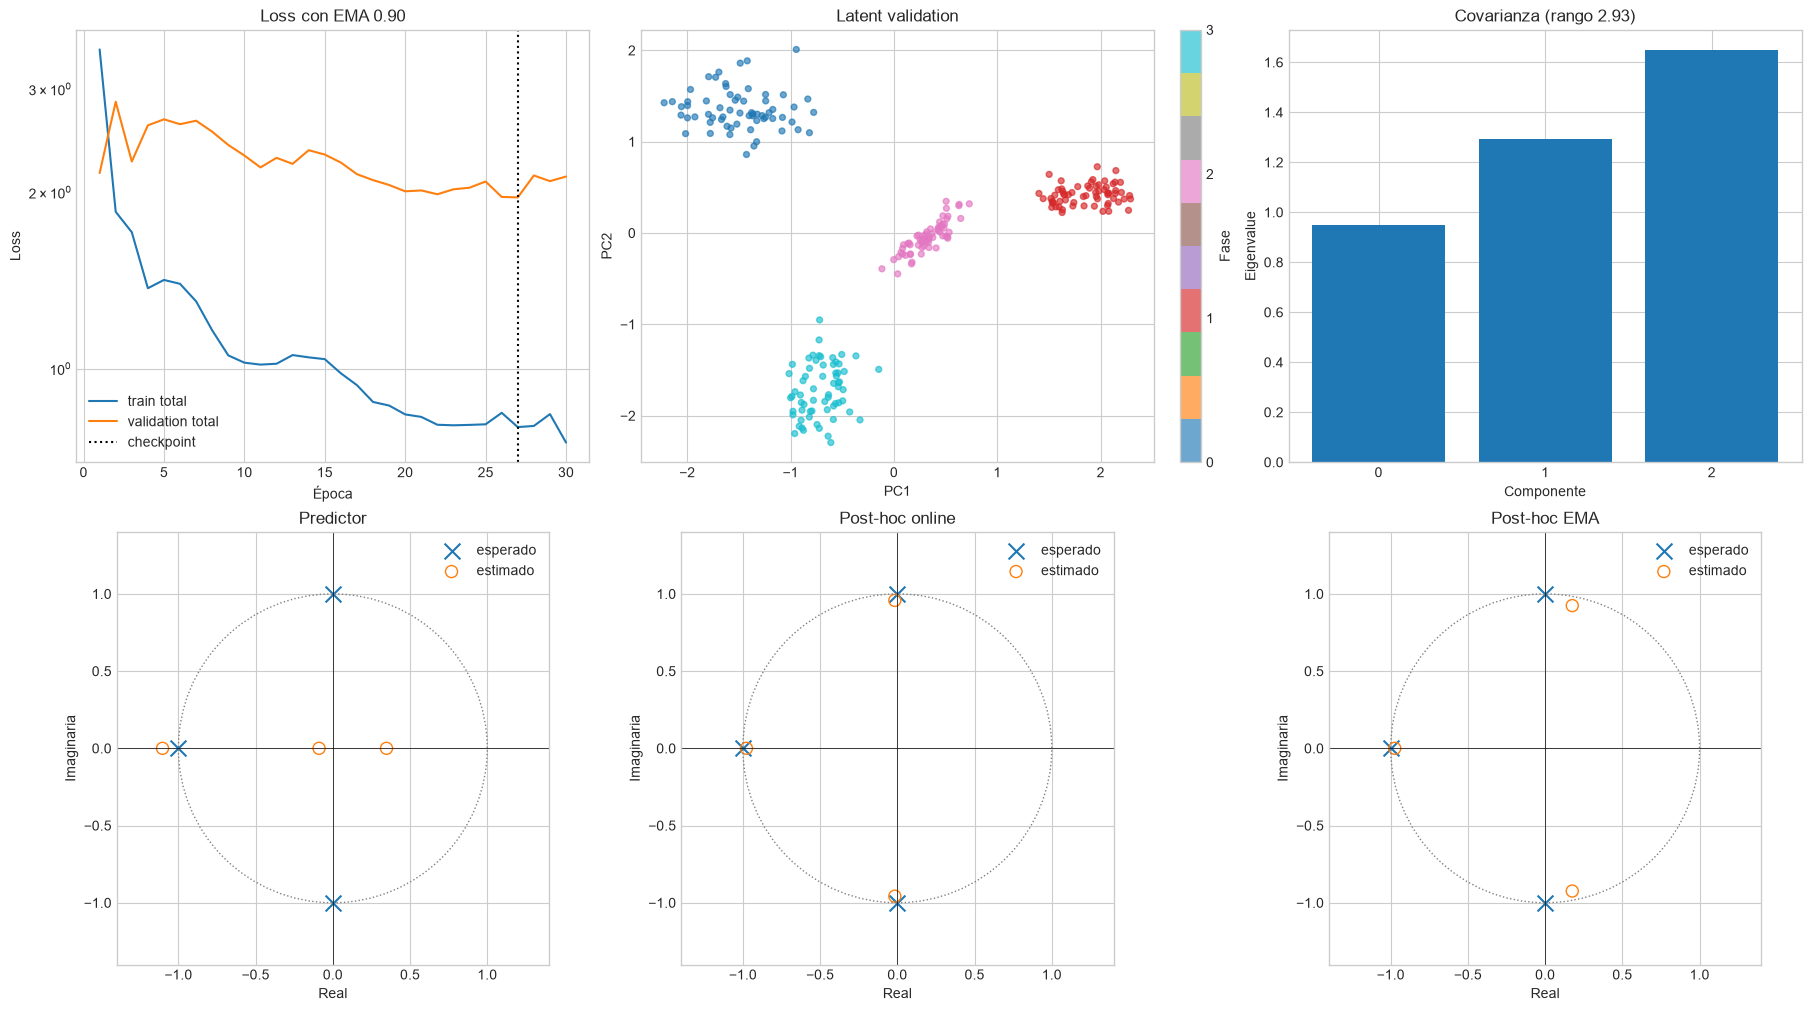

## Análisis del resultado

- Gate cíclico con EMA `0.90`: **FAIL**.
- Checkpoint: época **27**; ratio validation/baseline: **0.426**.
- Rango efectivo / probe de fase: **2.927 / 100.00%**.
- Error de alineación / entrelazamiento: **0.182 / 0.759**.
- Error espectral máximo del predictor: **1.059**.
- Diferencia de base online/EMA: **0.182** (referencia EMA `0.99`: `0.812`).
- Error espectral máximo post-hoc online: **0.045**.

La comparación causal relevante es con el smoke original: sólo cambió la velocidad del target. Un menor desacople online/EMA acompañado por mejor entrelazamiento y espectro apoyaría la hipótesis del lag; si la base se alinea pero el predictor sigue fallando, habrá que revisar la dinámica conjunta del predictor o la selección por loss. Este resultado sigue siendo una sola seed de desarrollo y no consulta test.


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
epochs = np.array([row["epoch"] for row in history])
axes[0, 0].plot(epochs, [row["train_loss"] for row in history], label="train total")
axes[0, 0].plot(epochs, [row["val_loss"] for row in history], label="validation total")
axes[0, 0].axvline(training_result.best_epoch, color="black", linestyle=":", label="checkpoint")
axes[0, 0].set(title="Loss con EMA 0.90", xlabel="Época", ylabel="Loss", yscale="log")
axes[0, 0].legend()
projection = PCA(n_components=2).fit_transform(validation_current)
scatter = axes[0, 1].scatter(projection[:, 0], projection[:, 1], c=validation_phase_pairs[:, 0], cmap="tab10", s=18, alpha=0.65)
axes[0, 1].set(title="Latent validation", xlabel="PC1", ylabel="PC2")
fig.colorbar(scatter, ax=axes[0, 1], ticks=np.arange(4), label="Fase")
axes[0, 2].bar(np.arange(3), metrics["covariance_eigenvalues"])
axes[0, 2].set(title=f"Covarianza (rango {metrics['effective_rank']:.2f})", xlabel="Componente", ylabel="Eigenvalue", xticks=np.arange(3))

operators = {"Predictor": predictor_matrix, "Post-hoc online": diagnostics["posthoc_online_operator"], "Post-hoc EMA": diagnostics["posthoc_target_operator"]}
expected = expected_active_spectrum(dynamics, emission_config.num_phases)
for axis, (name, operator) in zip(axes[1], operators.items(), strict=True):
    eigenvalues = np.linalg.eigvals(operator)
    axis.scatter(expected.real, expected.imag, marker="x", s=130, label="esperado")
    axis.scatter(eigenvalues.real, eigenvalues.imag, facecolors="none", edgecolors="tab:orange", s=75, label="estimado")
    axis.add_patch(plt.Circle((0, 0), 1, fill=False, linestyle=":", color="gray"))
    axis.axhline(0, color="black", linewidth=0.5)
    axis.axvline(0, color="black", linewidth=0.5)
    axis.set(title=name, xlabel="Real", ylabel="Imaginaria", aspect="equal", xlim=(-1.4, 1.4), ylim=(-1.4, 1.4))
    axis.legend()
plt.show()

display(Markdown(f"""## Análisis del resultado

- Gate cíclico con EMA `0.90`: **{'PASS' if ema_fast_gate_passed else 'FAIL'}**.
- Checkpoint: época **{training_result.best_epoch}**; ratio validation/baseline: **{validation_loss_ratio:.3f}**.
- Rango efectivo / probe de fase: **{metrics['effective_rank']:.3f} / {metrics['linear_probe_accuracy']:.2%}**.
- Error de alineación / entrelazamiento: **{metrics['phase_alignment_error']:.3f} / {metrics['intertwining_error']:.3f}**.
- Error espectral máximo del predictor: **{metrics['spectral_max_absolute_error']:.3f}**.
- Diferencia de base online/EMA: **{diagnostics['online_target_phase_basis_error']:.3f}** (referencia EMA `0.99`: `0.812`).
- Error espectral máximo post-hoc online: **{diagnostics['posthoc_online_spectral_max_error']:.3f}**.

La comparación causal relevante es con el smoke original: sólo cambió la velocidad del target. Un menor desacople online/EMA acompañado por mejor entrelazamiento y espectro apoyaría la hipótesis del lag; si la base se alinea pero el predictor sigue fallando, habrá que revisar la dinámica conjunta del predictor o la selección por loss. Este resultado sigue siendo una sola seed de desarrollo y no consulta test.
"""))